Loaded dataset and explored structure

In [427]:
import pandas as pd

df = pd.read_csv("quikr_car.csv")
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [428]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


Data Cleaning:
- Removed missing values
- Converted Price & Kms to numeric

In [429]:
df.describe()

,name,company,year,Price,kms_driven,fuel_type
count,892,892,892,892,840,837
unique,525,48,61,274,258,3
top,Honda City,Maruti,2015,Ask For Price,"45,000 kms",Petrol
freq,13,235,117,35,30,440


In [430]:
df.isnull().sum()

,0
name,0
company,0
year,0
Price,0
kms_driven,52
fuel_type,55


In [431]:
df = df.dropna()

In [432]:
df.isnull().sum()

,0
name,0
company,0
year,0
Price,0
kms_driven,0
fuel_type,0


In [433]:
df["year"] = df["year"].astype(int)

In [434]:
df = df[df["Price"] != "Ask For Price"]

df["Price"] = df["Price"].str.replace(",", "")

df["Price"] = df["Price"].astype(int)

In [435]:
df["kms_driven"] = df["kms_driven"].str.replace(",", "")
df["kms_driven"] = df["kms_driven"].str.replace(" kms", "")
df["kms_driven"] = df["kms_driven"].astype(int)

Exploratory Data Analysis (EDA):
- Price Distribution
- Year vs Price
- Fuel Type Distribution


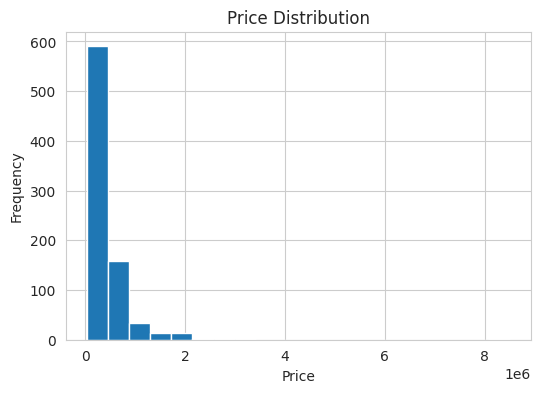

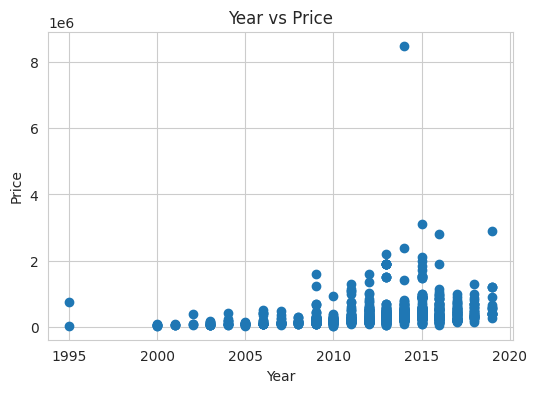

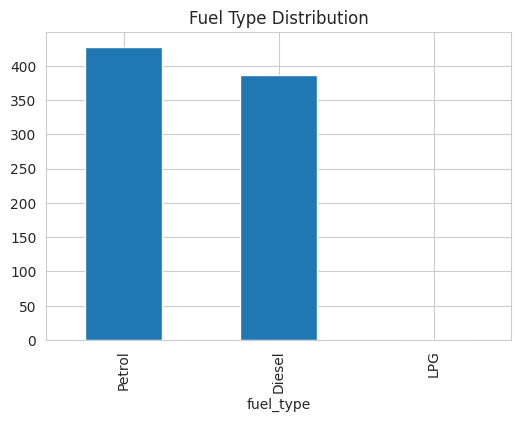

In [436]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["Price"].plot(kind="hist", bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print("\n\n")


plt.figure(figsize=(6,4))
plt.scatter(df["year"], df["Price"])
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Year vs Price")
plt.show()

print("\n\n")

plt.figure(figsize=(6,4))
df["fuel_type"].value_counts().plot(kind="bar")
plt.title("Fuel Type Distribution")
plt.show()

Feature Selection:

In [437]:
X = df.drop(["Price", "name"], axis=1)
y = df["Price"]

Converted categorical data → numerical


In [438]:
X = pd.get_dummies(X, drop_first=True)

In [439]:
X.head()

,year,kms_driven,company_BMW,company_Chevrolet,company_Datsun,company_Fiat,company_Force,company_Ford,company_Hindustan,company_Honda,...,company_Mitsubishi,company_Nissan,company_Renault,company_Skoda,company_Tata,company_Toyota,company_Volkswagen,company_Volvo,fuel_type_LPG,fuel_type_Petrol
0,2007,45000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2006,40,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2014,28000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2014,36000,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
6,2012,41000,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [440]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model Used: Linear Regression

In [441]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [442]:
y_pred = model.predict(X_test)

In [443]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.18776549825635502

Predicted vs Actual Price Comparison

In [444]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head())

     Actual      Predicted
204  135000   71738.062086
312  284999  271634.262610
791  189000  298243.163073
236  245000  232512.060087
570  215000  193343.132613
